This code will take in the "unbiased" adjusted c-Fos count map as an imput to conduct spatial factorization. This will be unbiased since the regression did not take into account the drug conditions (the dataset is only post hoc registered to the drug conditions).

In [1]:
import dataclasses
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import jax.random as jr
import wandb
import warnings

from datetime import datetime
from sklearn.model_selection import KFold
from fastprogress import progress_bar
import sys
# Add parent directory to system path
sys.path.append(r"C:\Users\stuberadmin\fos")

from fos import seminmf_full as seminmf

warnings.filterwarnings("ignore")

c:\Users\stuberadmin\anaconda3\envs\scanpy_py\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# set up paths
rootpath = r"\\10.159.50.7\LabCommon\Ken\data\Opioid_cFos"
result_dir = os.path.join(rootpath, "spatial_clustering_results")

In [3]:
WANDB_PROJECT = "morphine-fos-seminmf-counts"
RESULTS_DIR = os.path.join(result_dir,datetime.now().strftime("%Y_%m_%d-%H_%M"))

if not os.path.exists(RESULTS_DIR):
    os.mkdir(RESULTS_DIR)

## Combine all the per-mouse arrays into one file

In [4]:
# DATA_DIREC = "/scratch/groups/swl1/serotonin/npz_4"

# N = len(os.listdir(DATA_DIREC))
# height = 89
# width = 95
# depth = 80
# intensity_3d = np.zeros((N, height, width, depth), dtype=np.float32)
# counts_3d = np.zeros((N, height, width, depth), dtype=np.int16)
# inds = -1 * np.ones(N)

# for i, fname in enumerate(os.listdir(DATA_DIREC)):
#     # print(fname)
#     ind = int(fname[:3])
#     inds[i] = ind

#     npz = np.load(os.path.join(DATA_DIREC, fname))
#     coords = npz["coords"]
#     x, y, z = coords.T
#     intensity_3d[i][x, y, z] = npz["log_vs"]
#     counts_3d[i][x, y, z] = npz["Ns"]
    
# np.savez(os.path.join(DATA_DIREC, f"downsampled_data_4.npz"),
#          intensity=intensity_3d, counts=counts_3d, mouse_inds=inds)

## Load the combined data

In [5]:
# load the atlas image
import tifffile
# read an annotated atlas file
atlas_img = tifffile.imread(r"\\10.159.50.7\Analysis2\Ken\LSMS\ClearMap\clearmap_ressources_mouse_brain\ClearMap_ressources\Regions_annotations\Kim_ref_adult_FP-label_v4.0.tif")
contour_img = tifffile.imread(r"\\10.159.50.7\Analysis2\Ken\ClearMap\clearmap_ressources_mouse_brain\ClearMap_ressources\Regions_annotations\Kim_ref_adult_FP-label_v2.9_contour_map.tif")


In [6]:
# load the meta information
import pandas as pd
metadf = pd.read_csv(r"\\10.159.50.7\LabCommon\Ken\data\Opioid_cFos\meta\OP_meta.csv")
# Use only morphine related groups
Conditions = ['Saline','Acute_Morphine','Chronic_Morphine','Withdrawal_Morphine','Chronic_Morphine_21','Withdrawal_Morphine_21',]
print(Conditions)

# subset the meta dataframe
metadf = metadf[metadf.Condition.isin(Conditions)]

['Saline', 'Acute_Morphine', 'Chronic_Morphine', 'Withdrawal_Morphine', 'Chronic_Morphine_21', 'Withdrawal_Morphine_21']


In [7]:
import dask.array as da
analysis_resultpath = r"\\10.159.50.7\LabCommon\Ken\data\Opioid_cFos"
# load the dask array storing the heatmap
RAWDATA_FILE = os.path.join(r"\\10.159.50.7\LabCommon\Ken\data\Opioid_cFos",'heatmap_array')
raw_counts = da.from_zarr(RAWDATA_FILE, mode="r")

# read the adjusted heatmap, this is raw counts subtracted with background counts calcualted by linear regression 
DATA_FILE = os.path.join(r"\\10.159.50.7\LabCommon\Ken\data\Opioid_cFos\result",'unbiased_adjusted_brain_heatmap')
counts = da.from_zarr(DATA_FILE, mode="r")

# bg_counts will be a raw_counts - counts, 
bg_counts = raw_counts - counts

# load the fnames   
fnamelist = np.load(os.path.join(analysis_resultpath,'fnamelist.npy'))
assert len(fnamelist) == counts.shape[0]
#print(fnamelist)

In [8]:
# set raw_counts as counts
counts = raw_counts

In [9]:
# reorder the meta data frame
metadf = metadf.set_index('fname').loc[fnamelist].reset_index()

In [10]:
# intensity_3d = data["intensity"] remove
counts_3d = counts.reshape([counts.shape[0],] + list(atlas_img.shape)).compute() # reshape to atlas shape
mouse_inds = metadf.index


In [12]:
# get raw counts and background counts into 3d
#raw_counts_3d = counts.reshape([raw_counts.shape[0],] + list(atlas_img.shape)).compute() # reshape to atlas shape
bg_counts_3d = bg_counts.reshape([bg_counts.shape[0],] + list(atlas_img.shape)).compute() # reshape to atlas shape

In [13]:
assert counts_3d.shape[0] == 43

In [14]:
# the condition information will be located from the metadf 
drugs = metadf.Condition.values

### Remove the left edge to address edge effects

In [15]:
'''LEFT_TRUNC = 8
counts_3d = counts_3d[:, LEFT_TRUNC:, :, :]
intensity_3d = intensity_3d[:, LEFT_TRUNC:, :, :]
counts_3d.shape'''

'LEFT_TRUNC = 8\ncounts_3d = counts_3d[:, LEFT_TRUNC:, :, :]\nintensity_3d = intensity_3d[:, LEFT_TRUNC:, :, :]\ncounts_3d.shape'

### down sample data

In [22]:

import numpy as np
from skimage.transform import resize
from scipy.ndimage import median_filter

ds_key = False
input_voxel_size = (20,20,50)
target_voxel_size = (50,50,50)
if ds_key:
        
    # the original data is in 20,20,50 um voxel
    # this can be downsampled to THE TARGET VOXEL SIZE
    # these are in x,y,z order
    
    input_voxel_shape = atlas_img.shape
    target_voxel_shape = tuple(np.array(np.array(input_voxel_shape) * np.array(input_voxel_size)[::-1] / np.array(target_voxel_size)[::-1],dtype = 'int'))
    print(target_voxel_shape)

    # Resize with interpolation (anti_aliasing helps for float input)
    atlas_img_resized = resize(
        atlas_img,
        output_shape=target_voxel_shape,
        order=0,  # 1=linear interpolation (faster), 3=cubic
        mode='reflect',
        anti_aliasing=True
    )

    # Resize with interpolation (anti_aliasing helps for float input)
    contour_img_resized = resize(
        contour_img,
        output_shape=target_voxel_shape,
        order=1,  # 1=linear interpolation (faster), 3=cubic
        mode='reflect',
        anti_aliasing=False
    )

    # apply the resize to the counts_3d
    # the counts_3d is a 4D array with shape (n_samples, height, width, depth)
    counts_3d_resized = np.array([resize(
        f,
        output_shape=target_voxel_shape,
        order=0,  # 1=linear interpolation (faster), 3=cubic
        mode='reflect',
        anti_aliasing=False
    ) for f in counts_3d])

    # swap the variables
    #counts_3d = counts_3d_resized.astype(np.int16)
    #atlas_img = atlas_img_resized.astype(np.int16)


In [23]:
#plt.imshow(contour_img_resized[105,:,:])

### Only work with live voxels

In [24]:
#brain_voxels = atlas_img > 0
#counts_3d = counts_3d[:,brain_voxels]

In [25]:
alive_voxels = atlas_img > 0
print(np.sum(alive_voxels), "/", np.prod(counts_3d.shape[1:]), "voxels are 'alive'")

24453872 / 87750000 voxels are 'alive'


In [26]:
#intensity = intensity_3d[:, alive_voxels]
counts = counts_3d[:, alive_voxels]
bg_counts = bg_counts_3d[:, alive_voxels]
#raw_counts = raw_counts_3d[:, alive_voxels]
#intensity[counts == 0] = 0.0

In [27]:
# shif the counts value to non negative
bg_counts = bg_counts - np.min(bg_counts)

(<Axes: >, <matplotlib.image.AxesImage at 0x2230d1eddc0>)

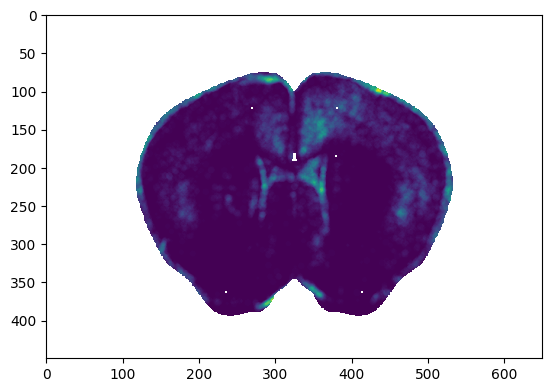

In [28]:
def plot_coronal(flat_array, z_idx, ax=None): # edit this so it works with my counts data, images are converted in to coronal planes already
    arr = jnp.nan * jnp.zeros(alive_voxels.shape)
    arr = arr.at[alive_voxels].set(flat_array)

    if ax is None:
        fig, ax = plt.subplots(1, 1)
    im = ax.imshow(arr[z_idx, :, :])
    return ax, im

#vis_intensity = jnp.where(counts == 0, jnp.nan, 0)

#plot_coronal(vis_intensity[0], 105)

plot_coronal(counts[10], 100)

### Make random masks

Mask off hyperrectangles for each mouse.

In [29]:
# def make_masks(key, size, num_rect_per_mouse=3):
MASK_KEY = 0
MASK_SIZE = 10
NUM_MASKS_PER_MOUSE = 3

key = jr.PRNGKey(MASK_KEY)
M, H, W, D = counts_3d.shape
masks_3d = jnp.ones_like(counts_3d, dtype=bool)

for m in progress_bar(range(M)):
    for i in range(NUM_MASKS_PER_MOUSE):
        k1, k2, k3, key = jr.split(key, 4)
        x,y,z = jr.randint(k1, (3,), minval=jnp.zeros(3), maxval=jnp.array([H, W, D]))
        masks_3d = masks_3d.at[m, x:x+MASK_SIZE, y:y+MASK_SIZE, z:z+MASK_SIZE].set(False)

masks = masks_3d[:, alive_voxels]


(<Axes: >, <matplotlib.image.AxesImage at 0x22311423680>)

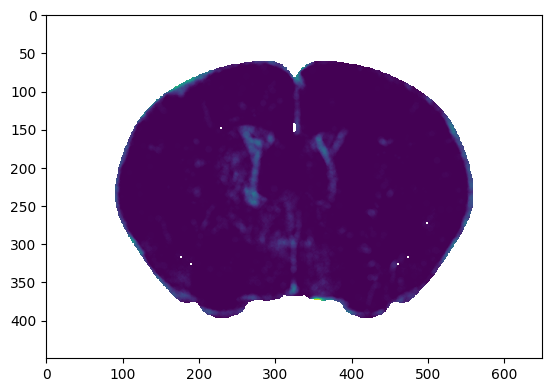

In [30]:
plot_coronal(jnp.where(masks[0], counts[0], jnp.nan), 120)

# Check if the average heatmaps are appropriate for each condition

In [31]:
del counts_3d, bg_counts_3d, masks_3d

## Select hyperparameters by cross validation

In [32]:
from importlib import reload
reload(seminmf)


<module 'fos.seminmf_full' from 'C:\\Users\\stuberadmin\\fos\\fos\\seminmf_full.py'>

In [42]:
# Convert to JAX arrays
counts = jnp.array(counts)
masks = jnp.array(masks)
bg_counts = jnp.array(bg_counts)

# ========== HYPERPARAMETER SEARCH ==========
print("\n=== STARTING HYPERPARAMETER SEARCH ===")

mean_func = "softplus"
elastic_net_frac = 1.0
num_iters = 15
num_coord_ascent_iters = 1
subsample_frac = 0.3

# Subsample voxels for faster computation
key = jr.PRNGKey(42)
n_voxels = int(counts.shape[1] * subsample_frac)
voxel_idx = jr.choice(key, counts.shape[1], (n_voxels,), replace=False)

sub_counts = counts[:, voxel_idx]
sub_masks = masks[:, voxel_idx]
sub_bg_counts = bg_counts[:, voxel_idx]
print(f"Using subsampled data: {sub_counts.shape} (original: {counts.shape})")



=== STARTING HYPERPARAMETER SEARCH ===
Using subsampled data: (43, 7336161) (original: (43, 24453872))


In [ ]:
'''# Code for poisson + gaussian seminmf fitting with wandb logging
import pickle
# set variables
max_num_factors = 25
seed = 42
num_coord_ascent_iters = 1
elastic_net_frac = 1.0
gaussian_var = None
wandb_project = WANDB_PROJECT
results_dir = RESULTS_DIR
mask_key = 'mask'  # Default mask key, can be overridden by command line argument
data_file = DATA_FILE
num_iters = 15

if gaussian_var is None:
    gaussian_var = float(np.var(sub_counts))

key = jr.PRNGKey(seed)
mean_func = 'softplus'
full_initial_params = seminmf.initialize_random(key, sub_counts, max_num_factors, mean_func)

all_sparsity_penalties = jnp.array([1e-4, 1e-3, 1e-2, 1e-1])
all_num_factors = jnp.arange(8, max_num_factors + 1, 2)
all_heldout_loglikes = -jnp.inf * jnp.ones((len(all_sparsity_penalties), len(all_num_factors)))


for i, sparsity_penalty in enumerate(all_sparsity_penalties):
    for j, num_factors in enumerate(all_num_factors):
        run = wandb.init(
            dir=results_dir,
            project=wandb_project,
            job_type='train',
            config=dict(
                sparsity_penalty=float(sparsity_penalty),
                num_factors=int(num_factors),
                elastic_net_frac=elastic_net_frac,
                max_num_iters=num_iters,
                num_coord_ascent_iters=num_coord_ascent_iters,
                model='poisson_bg_offset',
                initialization='random',
                data_file=data_file,
                mask_key=mask_key,
            ),
        )

        print(f'Fitting model with {float(sparsity_penalty)} sparsity and {int(num_factors)} factors')

        initial_params = dataclasses.replace(
            full_initial_params,
            factors=full_initial_params.factors[:num_factors],
            loadings=full_initial_params.loadings[:, :num_factors],
        )

        params, losses = seminmf.fit_poisson_seminmf(
            sub_counts,
            initial_params,
            mask=sub_masks,
            mean_func=mean_func,
            sparsity_penalty=float(sparsity_penalty),
            elastic_net_frac=elastic_net_frac,
            num_iters=num_iters,
            num_coord_ascent_iters=num_coord_ascent_iters,
            bg_counts=sub_bg_counts,
        )

        heldout_mask = ~sub_masks if sub_masks is not None else jnp.ones_like(sub_counts, dtype=bool)
        heldout_ll = -seminmf.smooth_loss(
            params,
            sub_counts,
            heldout_mask,
            mean_func,
            distribution='poisson',
            bg_counts=sub_bg_counts,
        )
        all_heldout_loglikes = all_heldout_loglikes.at[i, j].set(heldout_ll)

        result_file = os.path.join(results_dir, f'params_{i}_{j}.pkl')
        with open(result_file, 'wb') as f:
            pickle.dump(dict(params=params,
                                losses=np.array(losses),
                                sparsity_penalty=float(sparsity_penalty),
                                num_factors=int(num_factors),
                                heldout_loglike=float(heldout_ll)), f)

        run.summary['final_loss'] = float(losses[-1])
        run.summary['heldout_loglike'] = float(heldout_ll)
        artifact = wandb.Artifact(name=f'params_{i}_{j}', type='model')
        artifact.add_file(result_file)
        run.log_artifact(artifact)
        wandb.finish()

np.savez(
    os.path.join(results_dir, 'heldout_loglikes.npz'),
    heldout_loglikes=np.array(all_heldout_loglikes),
    sparsity_penalties=np.array(all_sparsity_penalties),
    num_factors=np.array(all_num_factors),
)'''

Fitting model with 9.999999747378752e-05 sparsity and 8 factors


Fitting model with 9.999999747378752e-05 sparsity and 10 factors


KeyboardInterrupt: 

In [44]:
# Code for full gaussian seminmf fitting with wandb logging
import pickle
# set variables
max_num_factors = 25
seed = 42
num_coord_ascent_iters = 1
elastic_net_frac = 1.0
gaussian_var = None
wandb_project = WANDB_PROJECT
results_dir = RESULTS_DIR
mask_key = 'mask'  # Default mask key, can be overridden by command line argument
data_file = DATA_FILE
num_iters = 15

if gaussian_var is None:
    gaussian_var = float(np.var(sub_counts))

key = jr.PRNGKey(seed)
mean_func = 'softplus'
full_initial_params = seminmf.initialize_random(key, sub_counts, max_num_factors, mean_func)

all_sparsity_penalties = jnp.array([1e-4, 1e-3, 1e-2, 1e-1])
all_num_factors = jnp.arange(8, max_num_factors + 1, 2)
all_heldout_loglikes = -jnp.inf * jnp.ones((len(all_sparsity_penalties), len(all_num_factors)))

for i, sparsity_penalty in enumerate(all_sparsity_penalties):
    for j, num_factors in enumerate(all_num_factors):
        run = wandb.init(
            dir=results_dir,
            project=wandb_project,
            job_type='train',
            config=dict(
                sparsity_penalty=float(sparsity_penalty),
                num_factors=int(num_factors),
                elastic_net_frac=elastic_net_frac,
                max_num_iters=num_iters,
                num_coord_ascent_iters=num_coord_ascent_iters,
                model='gaussian_softplus',
                initialization='random',
                data_file=data_file,
                mask_key=mask_key,
            ),
        )

        print(f'Fitting model with {float(sparsity_penalty)} sparsity and {int(num_factors)} factors')

        initial_params = dataclasses.replace(
            full_initial_params,
            factors=full_initial_params.factors[:num_factors],
            loadings=full_initial_params.loadings[:, :num_factors],
        )

        params, losses = seminmf.fit_gaussian_seminmf(
            sub_counts,
            initial_params,
            mask=sub_masks,
            mean_func=mean_func,
            sparsity_penalty=float(sparsity_penalty),
            elastic_net_frac=elastic_net_frac,
            num_iters=num_iters,
            num_coord_ascent_iters=num_coord_ascent_iters,
            gaussian_var=gaussian_var,
        )

        heldout_mask = ~sub_masks if sub_masks is not None else jnp.ones_like(sub_counts, dtype=bool)
        heldout_ll = -seminmf.smooth_loss(
            params,
            sub_counts,
            heldout_mask,
            mean_func,
            distribution='gaussian',
            gaussian_var=gaussian_var,
        )
        all_heldout_loglikes = all_heldout_loglikes.at[i, j].set(heldout_ll)

        result_file = os.path.join(results_dir, f'params_{i}_{j}.pkl')
        with open(result_file, 'wb') as f:
            pickle.dump(dict(params=params,
                                losses=np.array(losses),
                                sparsity_penalty=float(sparsity_penalty),
                                num_factors=int(num_factors),
                                heldout_loglike=float(heldout_ll),
                                gaussian_var=gaussian_var), f)

        run.summary['final_loss'] = float(losses[-1])
        run.summary['heldout_loglike'] = float(heldout_ll)
        artifact = wandb.Artifact(name=f'params_{i}_{j}', type='model')
        artifact.add_file(result_file)
        run.log_artifact(artifact)
        wandb.finish()

np.savez(
    os.path.join(results_dir, 'heldout_loglikes.npz'),
    heldout_loglikes=np.array(all_heldout_loglikes),
    sparsity_penalties=np.array(all_sparsity_penalties),
    num_factors=np.array(all_num_factors),
)

Fitting model with 9.999999747378752e-05 sparsity and 8 factors


KeyboardInterrupt: 

In [25]:

# Compute the SVD initialization once
max_num_factors = 25
full_initial_params = seminmf.initialize_nnsvd(sub_counts, max_num_factors, mean_func, drugs=None)

# Fit the model with different hyperparameters
all_sparsity_penalties = jnp.array([1e-4, 1e-3, 1e-2, 1e-1])
all_num_factors = jnp.arange(8, max_num_factors+1, 2)
all_heldout_loglikes = -jnp.inf * jnp.ones((len(all_sparsity_penalties), len(all_num_factors)))

print(f"\nTesting {len(all_sparsity_penalties)} sparsity penalties and {len(all_num_factors)} num_factors")

for i, sparsity_penalty in enumerate(all_sparsity_penalties):
    sparsity_penalty = sparsity_penalty.item()
    for j, num_factors in enumerate(all_num_factors):
        wandb.init(dir=analysis_resultpath, 
            # set the wandb project where this run will be logged
            project=WANDB_PROJECT,
            job_type="train",

            # track hyperparameters and run metadata
            config={
                "sparsity_penalty": sparsity_penalty,
                "num_factors": num_factors,
                "elastic_net_frac": elastic_net_frac,
                "max_num_iters": num_iters,
                "num_coord_ascent_iters": num_coord_ascent_iters,
                "mean_func": mean_func,
                "initialization": "nnsvd",
                "data_file": DATA_FILE,
                "mask_key": MASK_KEY,
                "mask_size": MASK_SIZE,
                "num_mask_per_mouse": NUM_MASKS_PER_MOUSE,
                "estimated_variance": estimated_data_variance,
                }
        )

        print(f"\nFitting model with sparsity={sparsity_penalty:.4f} and {num_factors} factors")
        initial_params = dataclasses.replace(
            full_initial_params,
            factors=full_initial_params.factors[:num_factors],
            count_loadings=full_initial_params.count_loadings[:, :num_factors],
        )

        params, losses, heldout_loglikes = \
        seminmf.fit_gaussian_seminmf(sub_counts,
                            initial_params,
                            mask=sub_masks,
                            mean_func=mean_func,
                            sparsity_penalty=sparsity_penalty,
                            elastic_net_frac=elastic_net_frac,
                            num_iters=num_iters,
                            num_coord_ascent_iters=num_coord_ascent_iters,
                            tolerance=1e-5,
                            data_variance=estimated_data_variance
                            )

        all_heldout_loglikes = all_heldout_loglikes.at[i, j].set(heldout_loglikes[-1])

        # Log results to wandb
        wandb.run.summary["final_loss"] = losses[-1]
        wandb.run.summary["heldout_loglike"] = heldout_loglikes[-1]
        wandb.run.summary["num_iterations"] = len(losses) - 1
        
        # Log loss curves
        for iter_idx, (loss, hll) in enumerate(zip(losses, heldout_loglikes)):
            wandb.log({
                "loss": loss,
                "heldout_loglike": hll,
                "iteration": iter_idx
            })
        
        wandb.finish()


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.



Testing 4 sparsity penalties and 9 num_factors


wandb: Currently logged in as: ken1223 (ken1223-university-of-washington). Use `wandb login --relogin` to force relogin



Fitting model with sparsity=0.0001 and 8 factors
Using data variance: 8.663590


AttributeError: module 'jax.numpy' has no attribute 'sigmoid'

## Evaluate the best fitting model

In [76]:
all_heldout_loglikes = all_heldout_loglikes.at[np.isnan(all_heldout_loglikes)].set(-1)
istar, jstar = jnp.unravel_index(jnp.argmax(all_heldout_loglikes), all_heldout_loglikes.shape)
best_sparsity_penalty = all_sparsity_penalties[istar]
best_num_factors = all_num_factors[jstar]
best_sparsity_penalty = float(best_sparsity_penalty)

print("Optimal sparsity penalty:", best_sparsity_penalty)
print("Optimal number of factors:", best_num_factors)

Optimal sparsity penalty: 9.999999747378752e-05
Optimal number of factors: 18


In [77]:
mean_func = "softplus"
elastic_net_frac = 1.0
num_iters = 500
num_coord_ascent_iters = 1

#best_sparsity_penalty = 0.01
#best_num_factors = 28

In [78]:
# Initialize a new wandb run
eval_run = wandb.init(dir=analysis_resultpath, 
    project=WANDB_PROJECT,
    job_type="eval",
    config={
        "sparsity_penalty": best_sparsity_penalty,
        "num_factors": best_num_factors,
        "elastic_net_frac": elastic_net_frac,
        "max_num_iters": num_iters,
        "num_coord_ascent_iters": num_coord_ascent_iters,
        "mean_func": mean_func,
        "initialization": "nnsvd",
        "data_file": DATA_FILE,
        "mask_key": MASK_KEY,
        "mask_size": MASK_SIZE,
        "num_mask_per_mouse": NUM_MASKS_PER_MOUSE,
        }
)

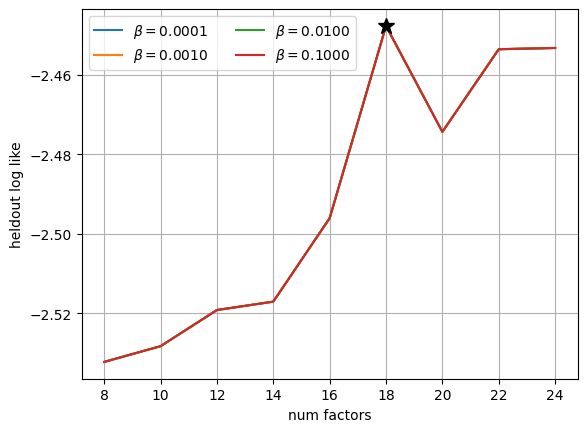

In [79]:
for j, sparsity_penalty in enumerate(all_sparsity_penalties):
    plt.plot(all_num_factors, all_heldout_loglikes[j], label=r"$\beta={:.4f}$".format(sparsity_penalty))
plt.plot(best_num_factors, all_heldout_loglikes[istar, jstar], 'k*', ms=12)
plt.xticks(all_num_factors)
plt.grid(True)
plt.xlabel("num factors")
plt.ylabel("heldout log like")
#plt.ylim(-0.022, -0.018)
plt.legend(ncols=2)
plt.savefig(os.path.join(RESULTS_DIR, "cross_val.png"))

wandb.log({"cross_val": wandb.Image(os.path.join(RESULTS_DIR, "cross_val.png"))})

## Fit model with a chosen number of factors on all data

In [80]:
initial_params = seminmf.initialize_nnsvd(counts, best_num_factors, mean_func, drugs=None)

TypeError: initialize_nnsvd() got an unexpected keyword argument 'drugs'

In [ ]:
sparsity_penalty = 1e-2
elastic_net_frac = 1.0
num_iters = 500
num_coord_ascent_iters = 1

print("fitting model with", best_num_factors, "factors")
params, losses, heldout_loglikes = \
    seminmf.fit_gaussian_seminmf(counts,
                        initial_params,
                        mask=None,
                        mean_func=mean_func,
                        sparsity_penalty=best_sparsity_penalty,
                        elastic_net_frac=elastic_net_frac,
                        num_iters=num_iters,
                        num_coord_ascent_iters=num_coord_ascent_iters,
                        tolerance=1e-6,
                        data_variance=estimated_data_variance  # Add this line
                            )


# Log results to wandb
wandb.run.summary["final_loss"] = losses[-1]

In [ ]:
plt.plot(losses)
plt.xlabel("iteration")
plt.ylabel("loss")

plt.savefig(os.path.join(RESULTS_DIR, "train_loss.png"))
#wandb.log({"traing_loss": wandb.Image(os.path.join(RESULTS_DIR, "train_loss.png"))})

In [ ]:
fig, axs = plt.subplots(3, 6, figsize=(30, 15), sharey=True, sharex=True)
for k, ax in enumerate(axs.ravel()):
    if k < best_num_factors:
        plot_coronal(params.factors[k], z_idx=85, ax=ax)
        ax.set_title("factor {}".format(k))
    else:
        ax.set_visible(False)
        
plt.tight_layout()

plt.savefig(os.path.join(RESULTS_DIR, "factors.png"), dpi=300)
#wandb.log({"factors": wandb.Image(os.path.join(RESULTS_DIR, "factors.png"))})

In [ ]:
# convert string values to integers using unique index
unique_drug_types = np.array(Conditions)
idx_drugs = np.array([np.where(unique_drug_types == drug)[0][0] for drug in drugs])


In [ ]:
idx_drugs

In [ ]:
perm = jnp.argsort(idx_drugs)
bounds = jnp.cumsum(jnp.bincount(idx_drugs))-0.5

loadings = params.count_loadings
vmax = abs(loadings).max()


In [ ]:
vmax

In [ ]:
fig,axs = plt.subplots(1,1,figsize= (4,6))
axs.imshow(loadings[perm], vmin=-vmax, vmax=vmax, cmap="coolwarm", aspect="auto", interpolation="none")
for bound in bounds:
    axs.axhline(bound, color='k')
_ = axs.set_xticks(np.arange(best_num_factors))

axs.set_xlabel("factor")
axs.set_ylabel("mouse")
axs.set_title("count loadings (sorted by drug group)")
#axs.colorbar()
fig.savefig(os.path.join(RESULTS_DIR, "count_loadings_by_drug.png"), dpi=300,bbox_inches = 'tight')
fig.savefig(os.path.join(RESULTS_DIR, "count_loadings_by_drug.pdf"), dpi=300,bbox_inches = 'tight')


In [ ]:

plt.figure()
plt.imshow(loadings[perm], vmin=-vmax, vmax=vmax, cmap="coolwarm", aspect="auto", interpolation="none")
for bound in bounds:
    plt.axhline(bound, color='k')
_ = plt.xticks(np.arange(best_num_factors))

plt.xlabel("factor")
plt.ylabel("mouse")
plt.title("count loadings (sorted by drug group)")
plt.colorbar()
plt.savefig(os.path.join(RESULTS_DIR, "count_loadings_by_drug.png"), dpi=300)
plt.savefig(os.path.join(RESULTS_DIR, "count_loadings_by_drug.pdf"), dpi=300)

#wandb.log({"count_loadings_by_drug": wandb.Image(os.path.join(RESULTS_DIR, "count_loadings_by_drug.png"))})


## Check downstream drug classification

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

# normalize weights and factors
def normalize_weights(weights):
    U = weights
    U = U - U.mean()
    U /= U.std()
    return(U)

def downstream_task(W, drugs, **kwargs):
    """
    kwargs
    ------
    cv: pass in the same CV splitter for both the grid search and the confusion matrix
    """
#     W_norm = normalize_weights(W)
    W_norm = W
    parameters = {"C":10 ** np.linspace(-15,15,num=31)}
    lr = LogisticRegression()
    gridsearch = GridSearchCV(lr, parameters, **kwargs)
    gridsearch.fit(W_norm, drugs)
    drug_clf_acc = gridsearch.best_score_
    classifier = gridsearch.best_estimator_
    drugs_pred = cross_val_predict(classifier, W_norm, y=drugs, **kwargs)
    confusion_mat = confusion_matrix(drugs, drugs_pred)
    return(classifier, drug_clf_acc, confusion_mat)

In [ ]:
features = jnp.hstack([normalize_weights(params.count_loadings),
                      ])
cv = KFold(shuffle=True, random_state=0)
clf, acc, cmat = downstream_task(features, drugs, cv=cv)

print(acc)
#wandb.run.summary["count drug acc"] = acc


plt.imshow(cmat)
plt.ylabel("true drug")
plt.xlabel("predicted drug")
plt.title("count loadings (acc={:.2f})".format(acc))
plt.colorbar()

plt.savefig(os.path.join(RESULTS_DIR, "count_intensity_confmat.png"), dpi=300)
#wandb.log({"count_intensity_confmat": wandb.Image(os.path.join(RESULTS_DIR, "count_intensity_confmat.png"))})

In [ ]:
Condition_figure_name = ['Saline','Acute','Chronic','Early WD','Re-exposure','Late WD'] 


In [ ]:
import seaborn as sns
features = jnp.hstack([normalize_weights(params.count_loadings),
#                        normalize_weights(params.intensity_loadings),
                      ])
cv = KFold(shuffle=True, random_state=0)
clf, acc, cmat = downstream_task(features, drugs, cv=cv)
print(acc)
#wandb.run.summary["count drug acc"] = acc

fig,axs = plt.subplots(1,1,figsize = (4,3.25))
sns.heatmap(cmat,ax = axs,cmap = 'viridis')
axs.set_title("count loadings (acc={:.2f})".format(acc))
axs.set_ylabel("true drug")
axs.set_xlabel("predicted drug")
#plt.colorbar(axs.images[0], ax=axs)

axs.set_xticks(np.array(range(len(Conditions))) + 0.5, Condition_figure_name, rotation=-45, ha='left')
axs.set_yticks(np.array(range(len(Conditions))) + 0.5, Condition_figure_name)

fig.savefig(os.path.join(RESULTS_DIR, "count_confmat.png"), dpi=216,bbox_inches = 'tight')
fig.savefig(os.path.join(RESULTS_DIR, "count_confmat.pdf"), dpi=216,bbox_inches = 'tight')

#wandb.log({"count_confmat": wandb.Image(os.path.join(RESULTS_DIR, "count_confmat.png"))})


## Sort factors by decoding importance

### Single feature decoding

In [ ]:
from fastprogress.fastprogress import master_bar, progress_bar

accs = -jnp.inf * jnp.ones(best_num_factors)
for j in progress_bar(range(best_num_factors)):
    features = jnp.column_stack([params.count_loadings[:,j:j+1],
                                 ])
    features = normalize_weights(features)
    cv = KFold(shuffle=True, random_state=0)
    _, acc, _ = downstream_task(features, drugs, cv=cv)
    accs = accs.at[j].set(acc)

factor_perm = jnp.argsort(accs)[::-1]
factor_perm

#wandb.run.summary["factor_perm_single"] = str(factor_perm)

In [ ]:
accs

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(range(len(accs)), accs[factor_perm])
plt.xlabel("Factor (sorted by decoding importance)")
plt.ylabel("Single factor decoding accuracy")
plt.title("Factor importance in drug classification")
plt.tight_layout()
plt.xticks(range(len(accs)), factor_perm, rotation=-45, ha='left')
plt.savefig(os.path.join(RESULTS_DIR, "factor_importance.pdf"))
plt.savefig(os.path.join(RESULTS_DIR, "factor_importance.png"), dpi=300)

### Greedy Forward
Use a greedy forward procedure where we build up the model one feature at a time, adding the feature that most improves the classification accuracy. Intuitively, we expect this approach to yield an ordering that is similar to the norm of the weights of the full decoder, but that's not strictly guaranteed.

In [ ]:
from fastprogress.fastprogress import master_bar, progress_bar

indices = jnp.array([], dtype=int)

mb = master_bar(range(best_num_factors))        
for i in mb:
    accs = -jnp.inf * jnp.ones(best_num_factors)
    for j in progress_bar(range(best_num_factors), parent=mb):
        if j not in indices:
            features = jnp.column_stack([params.count_loadings[:,indices],
                                        
                                         params.count_loadings[:,j],
                                         
                                        ])
            features = normalize_weights(features)
            cv = KFold(shuffle=True, random_state=0)
            _, acc, _ = downstream_task(features, drugs, cv=cv)
            accs = accs.at[j].set(acc)
            
    best_j = jnp.argmax(accs)
    indices = jnp.insert(indices, 0, best_j)

factor_perm = indices[::-1]    
factor_perm

#wandb.run.summary["factor_perm_greedyforward"] = str(factor_perm)

### Leave one out accuracy

How much does performance drop when we leave out one feature?

In [ ]:
# loo_acc = []

# for k in progress_bar(range(best_num_factors)):
    
#     features = jnp.hstack([params.count_loadings[:,:k],
#                            params.count_loadings[:,k+1:]])
#     features = normalize_weights(features)
#     cv = KFold(shuffle=True, random_state=0)
#     _, acc, _ = downstream_task(features, drugs, cv=cv)
#     loo_acc.append(acc)
    
# loo_acc = jnp.array(loo_acc)
# factor_perm = jnp.argsort(loo_acc)

In [ ]:
# features = normalize_weights(params.count_loadings)
# cv = KFold(shuffle=True, random_state=0)
# _, full_acc, _ = downstream_task(features, drugs, cv=cv)
# plt.bar(jnp.arange(best_num_factors), full_acc - loo_acc)

## Save factors to Python and matlab files

In [ ]:
import pickle
with open(os.path.join(RESULTS_DIR, "params.pkl"), 'wb') as f:
    pickle.dump(params, f)

artifact = wandb.Artifact(name="params_pkl", type="model")
artifact.add_file(local_path=os.path.join(RESULTS_DIR, "params.pkl"))
eval_run.log_artifact(artifact)

In [ ]:
from scipy.io import savemat
import numpy as onp
savemat(os.path.join(RESULTS_DIR, "params.mat"),
       dict(factors=onp.array(params.factors),
            count_loadings=onp.array(params.count_loadings),
            count_row_effects=onp.array(params.count_row_effects),
            count_col_effects=onp.array(params.count_col_effects),)

       )

#artifact = wandb.Artifact(name="params_mat", type="model")
#artifact.add_file(local_path=os.path.join(RESULTS_DIR, "params.mat"))
#eval_run.log_artifact(artifact)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from adjustText import adjust_text

# Set matplotlib parameters for white text on transparent background
plt.rcParams.update({
    'figure.facecolor': 'none',  # Transparent figure background
    'axes.facecolor': 'none',    # Transparent axes background
    'axes.edgecolor': 'black',   # White axes edge color
    'axes.labelcolor': 'black',  # White axis labels
    'xtick.color': 'black',      # White tick labels
    'ytick.color': 'black',      # White tick labels
    'legend.facecolor': 'none',  # Transparent legend background
    'legend.edgecolor': 'none',  # Transparent legend edgecolor
    'text.color': 'black',       # White text color
    'font.family':'Arial',
    'pdf.fonttype':42,
    'ps.fonttype':42,
   
})
#important for text to be detected when importing saved figures into illustrator


In [ ]:
count_loadings_df = pd.DataFrame(params.count_loadings,columns = [f'factor_{idx}' for idx in range(params.count_loadings.shape[1])])
# merge with metadf
count_loadings_df = count_loadings_df.join(metadf['Condition'])

In [ ]:
stack_count_loadings_df = count_loadings_df.set_index('Condition').stack().reset_index().rename(columns = {'level_1':'factor',0:'weights'})

In [ ]:
ave_stack_count_loadings_df = stack_count_loadings_df.groupby(['Condition','factor']).mean().reset_index().pivot(columns = 'factor',index = 'Condition',values = 'weights')
ave_stack_count_loadings_df = ave_stack_count_loadings_df.loc[Conditions,[f'factor_{idx}' for idx in range(22)]]

In [ ]:
Condition_color = ['gray','lime','orange','cyan','blue','purple']
Condition_figure_name = ['Saline','Acute','Chronic','Early WD','Re-exposure','Late WD'] 

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Create a results DataFrame to store ANOVA results
results = []

# Get unique factors
factors = stack_count_loadings_df['factor'].unique()

# Store raw p-values for multiple testing correction
raw_p_values = []

# For each factor, perform ANOVA
for factor in factors:
    # Subset data for current factor
    factor_data = stack_count_loadings_df[stack_count_loadings_df['factor'] == factor]
    
    # Get all conditions except Saline
    conditions = [c for c in factor_data['Condition'].unique() if c != 'Saline']
    
    # Perform one-way ANOVA
    groups = [factor_data[factor_data['Condition'] == 'Saline']['weights'].values]
    for condition in conditions:
        groups.append(factor_data[factor_data['Condition'] == condition]['weights'].values)
    
    # Perform ANOVA
    f_stat, p_value = stats.f_oneway(*groups)
    raw_p_values.append(p_value)
    
    # Store results with placeholder for corrected p-value
    results.append({
        'factor': factor,
        'f_statistic': f_stat,
        'p_value': p_value,
        'significant_comparisons': []  # Will be filled after multiple testing correction
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Perform multiple testing correction on ANOVA p-values
reject, pvals_corrected, _, _ = multipletests(raw_p_values, method='fdr_bh')

# Add corrected p-values to results DataFrame
results_df['corrected_p_value'] = pvals_corrected

# Now perform post-hoc tests only for factors with significant corrected p-values
for idx, row in results_df.iterrows():
    if row['corrected_p_value'] < 0.05:  # Using corrected p-value for decision
        factor = row['factor']
        factor_data = stack_count_loadings_df[stack_count_loadings_df['factor'] == factor]
        conditions = [c for c in factor_data['Condition'].unique() if c != 'Saline']
        
        significant_comparisons = []
        for condition in conditions:
            # Perform t-test between Saline and current condition
            saline_data = factor_data[factor_data['Condition'] == 'Saline']['weights'].values
            condition_data = factor_data[factor_data['Condition'] == condition]['weights'].values
            t_stat, p_val = stats.ttest_ind(saline_data, condition_data)
            
            if p_val < 0.05:
                significant_comparisons.append(f"Saline-{condition} (p={p_val:.4f})")
        
        # Update the significant comparisons in the results DataFrame
        results_df.at[idx, 'significant_comparisons'] = significant_comparisons

# Display results
print("\nANOVA Results:")
print(results_df)

# Print significant findings
print("\nSignificant Findings:")
for _, row in results_df.iterrows():
    if row['corrected_p_value'] < 0.05:
        print(f"\nFactor {row['factor']}:")
        print(f"ANOVA p-value: {row['p_value']:.4f}")
        print(f"Corrected p-value: {row['corrected_p_value']:.4f}")
        print("Significant comparisons with Saline:")
        for comp in row['significant_comparisons']:
            print(f"  - {comp}")

# write the results file
results_df.to_csv(os.path.join(RESULTS_DIR,'factor_anova_stat_df.csv'),index = False)

In [ ]:
# get the rejected factors
rejected_factor_idx = results_df.loc[results_df.corrected_p_value<0.05,'factor'].index

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Create directory for plots if it doesn't exist
tfigurepath = os.path.join(RESULTS_DIR, 'factors_by_condition')
if not os.path.exists(tfigurepath):
    os.mkdir(tfigurepath)

# Get unique factors from results_df
factors = results_df['factor'].unique()

def get_stars(p_value):
    """Return the appropriate number of stars based on p-value"""
    if p_value < 0.0001:
        return '****'
    elif p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    return ''

for factor in factors:
    # Create figure
    fig, axs = plt.subplots(1, 1, figsize=(2, 1.5))
    
    # Get the data for current factor
    factor_data = stack_count_loadings_df[stack_count_loadings_df.factor == factor]
    
    # Create strip plot
    sns.stripplot(data=factor_data,
                  y='weights',
                  x='Condition',
                  ax=axs,
                  palette=Condition_color,
                  order=Conditions,
                  alpha=0.5,
                  size=2)
    
    # Create point plot
    sns.pointplot(data=factor_data,
                  y='weights',
                  x='Condition',
                  palette=Condition_color,
                  order=Conditions,
                  ax=axs,
                  markers="o",
                  markersize=5,
                  linestyle="none",
                  linewidth=0.5)
    
    # Set y-axis limits
    #axs.set_ylim(-1.5E+07, 1.5E+07)
    
    # Add horizontal line at y=0
    axs.axhline(0, ls=':', color='gray', alpha=0.3)
    
    # Set x-axis labels
    axs.set_xticklabels(Condition_figure_name, rotation=-45)
    
    # Get significant comparisons for this factor
    significant_comps = results_df[results_df['factor'] == factor]['significant_comparisons'].iloc[0]
    
    # Add stars for significant comparisons
    if significant_comps:  # If there are any significant comparisons
        for comp in significant_comps:
            # Extract condition name and p-value from the comparison string
            condition = comp.split('-')[1].split(' ')[0]  # Gets the condition name from "Saline-Condition (p=...)"
            p_value = float(comp.split('p=')[1].split(')')[0])  # Gets the p-value from "Saline-Condition (p=0.xxxx)"
            
            # Find the x position of this condition
            x_pos = Conditions.index(condition)
            
            # Get the appropriate number of stars
            stars = get_stars(p_value)
            
            # Add stars above the condition
            if stars:  # Only add if there are stars to show
                axs.text(x_pos, axs.get_ylim()[1] * 0.95, stars, 
                        ha='center', va='bottom', fontsize=12)
    
    # Remove spines
    sns.despine()
    
    # Save the figure
    fig.savefig(os.path.join(tfigurepath, f'{factor}.png'), dpi=216, bbox_inches='tight')
    fig.savefig(os.path.join(tfigurepath, f'{factor}.pdf'), dpi=216, bbox_inches='tight')
    
    # Close the figure to free memory
    plt.close(fig)

In [ ]:
fig,axs = plt.subplots(1,1,figsize = (4,6))
sns.heatmap(data = ave_stack_count_loadings_df, cmap="coolwarm",vmin = -vmax//3,vmax = vmax//3,ax = axs)
axs.set_xticks(np.array(range(22)) + 0.5)
axs.set_yticklabels(Condition_figure_name,rotation = 90)
fig.savefig(os.path.join(RESULTS_DIR,'average_count_loadings.png'),dpi= 216,bbox_inches = 'tight')
fig.savefig(os.path.join(RESULTS_DIR,'average_count_loadings.pdf'),dpi= 216,bbox_inches = 'tight')

In [ ]:
# run an anova 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, to_rgba
import cv2
# 1. Automatic intensity adjustment
def adjust_intensity(image):
    min_val, max_val = np.min(image), np.max(image)
    return (image - min_val) / (max_val - min_val)

# 2. Convert base_image to color image using coolwarm colormap
def convert_to_coolwarm(image, cmin, cmax,colormap = plt.cm.viridis):
    norm = Normalize(vmin=cmin, vmax=cmax)
    return colormap(norm(image))

# 3. Maximize intensity of overlap_image and convert to color
def convert_overlap_image(image):
    norm_image = adjust_intensity(image)
    colormap = plt.cm.Greys  # Reverse grayscale; large values -> black
    return colormap(image)

# 4. Overlay the images
def overlay_images(base_color, overlap_color, alpha=0.5):
    #print(overlap_color)
    base_color[overlap_color == 0] = 1
    return base_color

# create a heatmap overlayed with a contour
def overlap_contour(base_image,overlap_image,cmin =  -100, cmax = 100,outputpath = False,colormap = plt.cm.viridis):
    # Load your data
    # Assuming `base_image` and `overlap_image` are already loaded as 3D numpy arrays.
    # Replace these with your data loading mechanism.
    #base_image = np.mean(norm_stm_array,axis = 0)
    #overlap_image = contour_img

    # Step 1: Adjust intensity of both images
    #base_image_adj = adjust_intensity(base_image)
    base_image_adj = base_image
    overlap_image_adj = adjust_intensity(overlap_image)

    # Step 2: Convert base_image to coolwarm colormap
      # Ensure symmetric range around 0
    base_image_color = convert_to_coolwarm(base_image_adj, cmin, cmax,colormap = colormap)

    # Step 3: Convert overlap_image to grayscale colormap
    overlap_image_color = convert_overlap_image(overlap_image_adj)

    # Step 4: Overlay the images
    overlayed_image = overlay_images(base_image_color, overlap_image_color, alpha=1)

    # write the result
    if outputpath:
        tifffile.imwrite(outputpath, overlayed_image)
    return base_image_adj,overlayed_image



## Save factors to tiff stack

In [ ]:
input_voxel_shape

In [ ]:
def upsample(arr, target_voxel_shape):
    """
    Upsample a 3D array to target voxel shape using nearest neighbor interpolation
    
    Args:
        arr: 3D numpy array to upsample
        target_voxel_shape: Tuple of (z,y,x) target dimensions
        
    Returns:
        Upsampled array with shape target_voxel_shape
    """
    from scipy.ndimage import zoom
    
    # Calculate zoom factors for each dimension
    zoom_factors = [t/c for t,c in zip(target_voxel_shape, arr.shape)]
    
    # Upsample using nearest neighbor interpolation
    upsampled = zoom(arr, zoom_factors, order=0)
    
    return upsampled
    

In [ ]:
from tifffile import imsave

def save_factor(factor, filename):
    arr = jnp.zeros(alive_voxels.shape)
    arr = arr.at[alive_voxels].set(factor)
    #arr = jnp.transpose(arr, (1, 2, 0))
    arr /= arr.max()
    #imsave(filename, arr)
    arr = upsample(arr,input_voxel_shape)
    np.save(filename, arr)
    
os.mkdir(os.path.join(RESULTS_DIR, "npy"))
for k, factor in enumerate(params.factors):
    fname = os.path.join(RESULTS_DIR, "npy", "factor{}.npy".format(k))
    save_factor(factor, fname)


In [ ]:
# Create zarr array to store factors
import zarr
import dask.array as da
from pathlib import Path

# Get shape from first factor
fname = os.path.join(RESULTS_DIR, "npy", "factor0.npy") 
first_factor = np.load(fname)
factor_shape = first_factor.flatten().shape

# Initialize zarr array with correct shape for all factors
zarr_path = os.path.join(RESULTS_DIR, "factors.zarr")
z = zarr.open(zarr_path, mode='w', shape=(22, *factor_shape), chunks=(1, *factor_shape), dtype=np.float32)

# Write each factor one at a time
for k in range(22):
    fname = os.path.join(RESULTS_DIR, "npy", f"factor{k}.npy")
    # Load as dask array to avoid loading into memory
    factor_da = da.from_array(np.load(fname))
    # Write to zarr array
    z[k] = factor_da.flatten()


In [ ]:
RESULTS_DIR

In [ ]:
# read the zarr file as a dask.array
factors_da = da.from_zarr(os.path.join(RESULTS_DIR, "factors.zarr"))
factors_da

In [ ]:
np.max(theatmap)

In [ ]:
import contour_visualization2 as cv2

# pre selected zplanes
curated_zplanes = [84,104,117,153,186,220]
# slice for visualization
imy_slice = slice(int(25),int(425))
imx_slice = slice(int(50),int(600))

if not os.path.exists(os.path.join(RESULTS_DIR,'selected_regions')):
    os.mkdir(os.path.join(RESULTS_DIR,'selected_regions'))

from tqdm import tqdm

for k in tqdm(range(22)):
    
    # read the npy
    fname = os.path.join(RESULTS_DIR, "npy", "factor{}.npy".format(k))
    theatmap = np.load(fname)
    
    # plot every 10 zplanes
    fig,axs = plt.subplots(1,len(curated_zplanes),figsize = (3*len(curated_zplanes),3),sharey = True)
    fig.subplots_adjust(wspace=0.25, hspace=0.3)
    for idx,ax in enumerate(axs):
        formatted_idx = f"{curated_zplanes[idx]:04}" 
        
        
        __,overlayed_image = overlap_contour(theatmap,contour_img,\
        cmin =  -0.1, cmax = 0.1,\
        outputpath = None,colormap = plt.cm.coolwarm)
        ax.imshow(overlayed_image[curated_zplanes[idx],imy_slice,imx_slice,:])
        ax.axis('off')
        ax.set_title('')
        ax.set_ylabel(f"factor{k}",color = 'black')
    fig.savefig(os.path.join(RESULTS_DIR,'selected_regions',f'factor{k}_selected_regions.png'),bbox_inches='tight',dpi = 1024)
    fig.savefig(os.path.join(RESULTS_DIR,'selected_regions',f'factor{k}_selected_regions.pdf'),bbox_inches='tight',dpi = 1024)


In [ ]:
import contour_visualization2 as cv2

# pre selected zplanes
curated_zplane = 104
# slice for visualization
imy_slice = slice(int(25),int(425))
imx_slice = slice(int(50),int(600))

if not os.path.exists(os.path.join(RESULTS_DIR,'selected_regions')):
    os.mkdir(os.path.join(RESULTS_DIR,'selected_regions'))

from tqdm import tqdm

fig,axs = plt.subplots(1,22,figsize = (15,3),sharey = True)
fig.subplots_adjust(wspace=0.25, hspace=0.3)
for k in tqdm(range(22)):
    # read the npy
    fname = os.path.join(RESULTS_DIR, "npy", "factor{}.npy".format(k))
    theatmap = np.load(fname)
    
    # plot every 10 zplanes

    # plot every 10 zplanes
    ax = axs[k]

    formatted_idx = f"{curated_zplanes[idx]:04}" 
    
    
    __,overlayed_image = overlap_contour(theatmap,contour_img,\
    cmin =  0, cmax = 0.00015,\
    outputpath = None,colormap = plt.cm.viridis)
    ax.imshow(overlayed_image[curated_zplane,imy_slice,imx_slice,:])
    ax.axis('off')
    ax.set_title(f"factor{k}",color = 'black')
fig.savefig(os.path.join(RESULTS_DIR,'selected_regions',f'curated_zplane{curated_zplane}_factors.png'),bbox_inches='tight',dpi = 1024)
fig.savefig(os.path.join(RESULTS_DIR,'selected_regions',f'curated_zplane{curated_zplane}_factors.pdf'),bbox_inches='tight',dpi = 1024)


In [ ]:
'''
artifact = wandb.Artifact(name="factor_tiffs", type="tif")
artifact.add_dir(local_path=os.path.join(RESULTS_DIR, "tiff"))
eval_run.log_artifact(artifact)'''

In [ ]:
RESULTS_DIR

### Finish the WANDB Run

In [ ]:
wandb.finish()

# Figure 6: spatial analysis of NAc

In [ ]:
import create_mask_for_region

In [ ]:
atlas_df = pd.read_csv(r"\\10.159.50.7\Analysis2\Ken\ClearMap\clearmap_ressources_mouse_brain\ClearMap_ressources\Regions_annotations\atlas_info_KimRef_FPbasedLabel_v4.0_brain_with_size_with_curated_with_cleaned_acronyms.csv",index_col = False)

conduct analysis of NAc distribution

In [ ]:
# target site can be experiment specific
target_site_acronym = 'Acb'
target_site_id = atlas_df.loc[atlas_df.acronym == target_site_acronym,'id'].values[0]
target_site_subids = create_mask_for_region.get_subregions(atlas_df,target_site_id,return_original=True)['id'].values
target_site_subacronyms = create_mask_for_region.get_subregions(atlas_df,target_site_id,return_original=True)['acronym'].values

In [ ]:
# collect all the z positions where there is the target site
zs = np.array([])
for ID in target_site_subids:
    z_,y_,x_ = np.where(atlas_img == ID)
    zs = np.concatenate([zs,z_])
# find the center of mass of the VTA
z_unique = np.unique(zs).astype('uint16')
z_center = int(np.mean(zs))

In [ ]:
subset_heatmap = np.reshape(factors_da,[22] + list(atlas_img.shape)).compute()

In [ ]:
subset_heatmap.shape

In [ ]:
# calculate the spatial distribution of c-Fos+ cells for each subject
spatial_cell_count_for_subregion = np.array([[[np.nanmean(subset_heatmap[f,z,np.where(atlas_img[z,:,:] == target_site_subid)[0],np.where(atlas_img[z,:,:] == target_site_subid)[1]]) for z in z_unique] for target_site_subid in target_site_subids] for f in range(22)])
# append spatial_c

In [ ]:
# calculate cell count for full region
spatial_cell_count_for_full = np.nansum(spatial_cell_count_for_subregion,axis = 1)

In [ ]:
np.save(os.path.join(analysis_resultpath,f'spatial_factors_for_subregion_sum_{target_site_acronym}.npy'),spatial_cell_count_for_full,)
np.save(os.path.join(analysis_resultpath,f'spatial_factors_for_subregion_{target_site_acronym}.npy'),spatial_cell_count_for_subregion,)

In [ ]:
# split the Acumbens into anterior middle posterior
z_anterior,z_medial,z_posterior = np.array_split(z_unique, 3)

In [ ]:
from statannotations.Annotator import Annotator
pairs = [("Saline","Acute_Morphine"),("Saline","Chronic_Morphine"),("Saline","Withdrawal_Morphine"),
("Chronic_Morphine","Acute_Morphine"),("Withdrawal_Morphine","Acute_Morphine"),("Withdrawal_Morphine","Chronic_Morphine"),]

for tidx, target_site_subid in enumerate(target_site_subids[:3]):
    #fig,axs = plt.subplots(1,1,figsize = (4,2))
    target_region = atlas_df.loc[atlas_df['id'] == target_site_subid,'acronym'].values[0]
    tdf_all = pd.read_csv(os.path.join(analysis_figurepath,f'cell_count_{target_region}_spatial_distibution.csv'),index_col = 0)

    # find rows in tdf_all that have valuse in column zposition that are contained in z_anterior
    fig,axs = plt.subplots(1,3,figsize = (1.5*3,2*1),sharey = True)
    sub_tdf_all = tdf_all[tdf_all.Condition.isin(Conditions)]
    for zidx,z_ in enumerate([z_anterior,z_medial,z_posterior]):
        df = sub_tdf_all[sub_tdf_all.zposition.isin(z_ - min(z_anterior))]
        df = df.groupby(['Condition','subject']).mean().reset_index()
        sns.boxplot(data = df,order = Conditions,
        x = 'Condition',y = 'density',ax = axs[zidx],palette = Condition_color)
        #sns.swarmplot(data = sub_tdf_all[sub_tdf_all.zposition.isin(z_medial - min(z_anterior))],
        # x = 'Condition',y = 'density',ax = axs,palette = Condition_color[:4],dodge = True,linewidth = 1,edgecolor = 'k') 
        axs[zidx].set_xticklabels(Condition_figure_name,rotation = -45)
        axs[zidx].set_title(['anterior','medial','posterior'][zidx])
        sns.despine()

        annotator = Annotator(axs[zidx], pairs, data=df, x='Condition', y='density', order=Conditions[:4])
        annotator.configure(test='t-test_ind', text_format='star', loc='outside',)
        annotator.configure(comparisons_correction="BH", correction_format="replace")
        annotator.apply_and_annotate()
        axs[zidx].set_ylim(0,15)

    fig.savefig(os.path.join(analysis_figurepath,f'cell_count_{target_region}_spatial_distibution_boxplot.png'),bbox_inches='tight',dpi = 512)
    fig.savefig(os.path.join(analysis_figurepath,f'cell_count_{target_region}_spatial_distibution_boxplot.pdf'),bbox_inches='tight',dpi = 512)

In [ ]:
# subset to NAc region
xslice = slice(325,325+120)
yslice = slice(240,240+120)

In [ ]:
for  idx,sub_acronym in enumerate(target_site_subacronyms):
    sub_factors = [1,2]
    #tarray = spatial_cell_count_for_subregion[rejected_factor_idx,idx,:]
    tarray = spatial_cell_count_for_subregion[sub_factors,idx,:]
    tarray = tarray[:,~np.isnan(tarray[0,:])]


    fig,axs = plt.subplots(1,1,figsize = (3,0.3))
    sns.heatmap(tarray,ax = axs,cmap = 'viridis',vmin = 0,vmax= 5E-5)
    axs.set_title(sub_acronym)
    axs.set_yticks(np.array(range(len(sub_factors))) + 0.5)
    axs.set_yticklabels(sub_factors,rotation = 0)
    axs.set_xticks([0,tarray.shape[1]])
    axs.set_xticklabels(['anterior','posterior'])    
    axs.set_ylabel('factor')
    axs.set_xlabel('z position')
    fig.savefig(os.path.join(RESULTS_DIR,f'{sub_acronym}_factors_spatial_distribution.png'),bbox_inches='tight',dpi = 512)
    fig.savefig(os.path.join(RESULTS_DIR,f'{sub_acronym}_factors_spatial_distribution.pdf'),bbox_inches='tight',dpi = 512)



In [ ]:
# plot the spatial distribution of starter cells for each subject



for cidx, __ in enumerate(range(22)):
    fig, axs = plt.subplots(1, len(z_unique[::5]), figsize=(len(z_unique[::5])*1.0, 1), sharex=True,sharey = True)
    theatmap = factors_da[cidx,:].reshape(atlas_img.shape).compute()
    __,overlayed_image = overlap_contour(theatmap[:,:,::-1],contour_img,\
        cmin =  0, cmax = 0.00015,\
        outputpath = None)
    for idx, curated_zplane in enumerate(z_unique[::5]):
        ax = axs[idx]
        ax.imshow(overlayed_image[curated_zplane,yslice,xslice])
        ax.set_xticks([])  # Remove x ticks
        ax.set_yticks([])  # Remove y ticks
        #ax.axis('off')
        if idx == 0:
            ax.set_ylabel(f'factor:{cidx}', color='black', )
        else:
            ax.set_ylabel('', color='black',)
    fig.savefig(os.path.join(RESULTS_DIR,f'{target_site_acronym}_factors_{cidx}_spatial_distibution.png'),bbox_inches='tight',dpi = 512)
    fig.savefig(os.path.join(RESULTS_DIR,f'{target_site_acronym}_factors_{cidx}_spatial_distibution.pdf'),bbox_inches='tight',dpi = 512)

# Figure 6: spatial analysis of Ce

conduct analysis of NAc distribution

In [ ]:
results_df = pd.read_csv(os.path.join(RESULTS_DIR,'factor_anova_stat_df.csv'),index_col = False)

In [ ]:
rejected_factor_idx = results_df[results_df.corrected_p_value < 0.05].index

In [ ]:
# target site can be experiment specific
target_site_acronym = 'Ce'
target_site_id = atlas_df.loc[atlas_df.acronym == target_site_acronym,'id'].values[0]
target_site_subids = create_mask_for_region.get_subregions(atlas_df,target_site_id,return_original=True)['id'].values

In [ ]:
target_site_subacronyms = create_mask_for_region.get_subregions(atlas_df,target_site_id,return_original=True)['acronym'].values

In [ ]:
# collect all the z positions where there is the target site
zs = np.array([])
for ID in target_site_subids:
    z_,y_,x_ = np.where(atlas_img == ID)
    zs = np.concatenate([zs,z_])
# find the center of mass of the VTA
z_unique = np.unique(zs).astype('uint16')
z_center = int(np.mean(zs))

In [ ]:
subset_heatmap = np.reshape(factors_da,[22] + list(atlas_img.shape)).compute()

In [ ]:
# calculate the spatial distribution of c-Fos+ cells for each subject
spatial_cell_count_for_subregion = np.array([[[np.nanmean(subset_heatmap[f,z,np.where(atlas_img[z,:,:] == target_site_subid)[0],np.where(atlas_img[z,:,:] == target_site_subid)[1]]) for z in z_unique] for target_site_subid in target_site_subids] for f in range(22)])
# append spatial_c

In [ ]:
# calculate cell count for full region
spatial_cell_count_for_full = np.nansum(spatial_cell_count_for_subregion,axis = 1)

In [ ]:
np.save(os.path.join(analysis_resultpath,f'spatial_factors_for_subregion_sum_{target_site_acronym}.npy'),spatial_cell_count_for_full,)
np.save(os.path.join(analysis_resultpath,f'spatial_factors_for_subregion_{target_site_acronym}.npy'),spatial_cell_count_for_subregion,)

In [ ]:
# split the Acumbens into anterior middle posterior
z_anterior,z_medial,z_posterior = np.array_split(z_unique, 3)

In [ ]:
# subset to Ce region
xslice = slice(420,420+120)
yslice = slice(245,245+120)

In [ ]:
for  idx,sub_acronym in enumerate(target_site_subacronyms):
    sub_factors = [1,2]
    #tarray = spatial_cell_count_for_subregion[rejected_factor_idx,idx,:]
    tarray = spatial_cell_count_for_subregion[sub_factors,idx,:]
    tarray = tarray[:,~np.isnan(tarray[0,:])]


    fig,axs = plt.subplots(1,1,figsize = (3,0.3))
    sns.heatmap(tarray,ax = axs,cmap = 'viridis',vmin = 0,vmax= 5E-5)
    axs.set_title(sub_acronym)
    axs.set_yticks(np.array(range(len(sub_factors))) + 0.5)
    axs.set_yticklabels(sub_factors,rotation = 0)
    axs.set_xticks([0,tarray.shape[1]])
    axs.set_xticklabels(['anterior','posterior'])    
    axs.set_ylabel('factor')
    axs.set_xlabel('z position')
    fig.savefig(os.path.join(RESULTS_DIR,f'{sub_acronym}_factors_spatial_distribution.png'),bbox_inches='tight',dpi = 512)
    fig.savefig(os.path.join(RESULTS_DIR,f'{sub_acronym}_factors_spatial_distribution.pdf'),bbox_inches='tight',dpi = 512)



In [ ]:
# plot the spatial distribution of starter cells for each subject
if not os.path.exists(os.path.join(RESULTS_DIR,f'{target_site_acronym}_factors')):
    os.mkdir(os.path.join(RESULTS_DIR,f'{target_site_acronym}_factors'))


for cidx, __ in enumerate(range(22)):
    fig, axs = plt.subplots(1, len(z_unique[::5]), figsize=(len(z_unique[::5])*1.0, 1), sharex=True,sharey = True)
    theatmap = factors_da[cidx,:].reshape(atlas_img.shape).compute()
    __,overlayed_image = overlap_contour(theatmap[:,:,::-1],contour_img,\
        cmin =  0, cmax = 0.00015,\
        outputpath = None)
    for idx, curated_zplane in enumerate(z_unique[::5]):
        ax = axs[idx]
        ax.imshow(overlayed_image[curated_zplane,yslice,xslice])
        ax.set_xticks([])  # Remove x ticks
        ax.set_yticks([])  # Remove y ticks
        #ax.axis('off')
        if idx == 0:
            ax.set_ylabel(f'factor:{cidx}', color='black', )
        else:
            ax.set_ylabel('', color='black',)
    fig.savefig(os.path.join(RESULTS_DIR,f'{target_site_acronym}_factors',f'{target_site_acronym}_factors_{cidx}_spatial_distibution.png'),bbox_inches='tight',dpi = 512)
    fig.savefig(os.path.join(RESULTS_DIR,f'{target_site_acronym}_factors',f'{target_site_acronym}_factors_{cidx}_spatial_distibution.pdf'),bbox_inches='tight',dpi = 512)

# Figure 6: spatial analysis of BLA

conduct analysis of NAc distribution

In [ ]:
results_df = pd.read_csv(os.path.join(RESULTS_DIR,'factor_anova_stat_df.csv'),index_col = False)

In [ ]:
rejected_factor_idx = results_df[results_df.corrected_p_value < 0.05].index

In [ ]:
# target site can be experiment specific
target_site_acronym = 'BLA'
target_site_id = atlas_df.loc[atlas_df.acronym == target_site_acronym,'id'].values[0]
target_site_subids = create_mask_for_region.get_subregions(atlas_df,target_site_id,return_original=True)['id'].values

In [ ]:
target_site_subacronyms = create_mask_for_region.get_subregions(atlas_df,target_site_id,return_original=True)['acronym'].values

In [ ]:
# collect all the z positions where there is the target site
zs = np.array([])
for ID in target_site_subids:
    z_,y_,x_ = np.where(atlas_img == ID)
    zs = np.concatenate([zs,z_])
# find the center of mass of the VTA
z_unique = np.unique(zs).astype('uint16')
z_center = int(np.mean(zs))

In [ ]:
subset_heatmap = np.reshape(factors_da,[22] + list(atlas_img.shape)).compute()

In [ ]:
# calculate the spatial distribution of c-Fos+ cells for each subject
spatial_cell_count_for_subregion = np.array([[[np.nanmean(subset_heatmap[f,z,np.where(atlas_img[z,:,:] == target_site_subid)[0],np.where(atlas_img[z,:,:] == target_site_subid)[1]]) for z in z_unique] for target_site_subid in target_site_subids] for f in range(22)])
# append spatial_c

In [ ]:
# calculate cell count for full region
spatial_cell_count_for_full = np.nansum(spatial_cell_count_for_subregion,axis = 1)

In [ ]:
np.save(os.path.join(analysis_resultpath,f'spatial_factors_for_subregion_sum_{target_site_acronym}.npy'),spatial_cell_count_for_full,)
np.save(os.path.join(analysis_resultpath,f'spatial_factors_for_subregion_{target_site_acronym}.npy'),spatial_cell_count_for_subregion,)

In [ ]:
# split the Acumbens into anterior middle posterior
z_anterior,z_medial,z_posterior = np.array_split(z_unique, 3)

In [ ]:
# subset to Ce region
xslice = slice(420,420+120)
yslice = slice(245,245+120)

In [ ]:
spatial_cell_count_for_full.shape

In [ ]:
sub_factors = [1,2]
#tarray = spatial_cell_count_for_subregion[rejected_factor_idx,idx,:]
tarray = spatial_cell_count_for_full[sub_factors,:]
tarray = tarray[:,~np.isnan(tarray[0,:])]


fig,axs = plt.subplots(1,1,figsize = (3,0.3))
sns.heatmap(tarray,ax = axs,cmap = 'viridis',vmin = 0,vmax= 5E-5)
axs.set_title(target_site_acronym)
axs.set_yticks(np.array(range(len(sub_factors))) + 0.5)
axs.set_yticklabels(sub_factors,rotation = 0)
axs.set_xticks([0,tarray.shape[1]])
axs.set_xticklabels(['anterior','posterior'])    
axs.set_ylabel('factor')
axs.set_xlabel('z position')
fig.savefig(os.path.join(RESULTS_DIR,f'{target_site_acronym}_factors_spatial_distribution.png'),bbox_inches='tight',dpi = 512)
fig.savefig(os.path.join(RESULTS_DIR,f'{target_site_acronym}_factors_spatial_distribution.pdf'),bbox_inches='tight',dpi = 512)



# Figure 6: spatial analysis of La

conduct analysis of NAc distribution

In [ ]:
results_df = pd.read_csv(os.path.join(RESULTS_DIR,'factor_anova_stat_df.csv'),index_col = False)

In [ ]:
rejected_factor_idx = results_df[results_df.corrected_p_value < 0.05].index

In [ ]:
# target site can be experiment specific
target_site_acronym = 'La'
target_site_id = atlas_df.loc[atlas_df.acronym == target_site_acronym,'id'].values[0]
target_site_subids = create_mask_for_region.get_subregions(atlas_df,target_site_id,return_original=True)['id'].values

In [ ]:
target_site_subacronyms = create_mask_for_region.get_subregions(atlas_df,target_site_id,return_original=True)['acronym'].values

In [ ]:
# collect all the z positions where there is the target site
zs = np.array([])
for ID in target_site_subids:
    z_,y_,x_ = np.where(atlas_img == ID)
    zs = np.concatenate([zs,z_])
# find the center of mass of the VTA
z_unique = np.unique(zs).astype('uint16')
z_center = int(np.mean(zs))

In [ ]:
subset_heatmap = np.reshape(factors_da,[22] + list(atlas_img.shape)).compute()

In [ ]:
# calculate the spatial distribution of c-Fos+ cells for each subject
spatial_cell_count_for_subregion = np.array([[[np.nanmean(subset_heatmap[f,z,np.where(atlas_img[z,:,:] == target_site_subid)[0],np.where(atlas_img[z,:,:] == target_site_subid)[1]]) for z in z_unique] for target_site_subid in target_site_subids] for f in range(22)])
# append spatial_c

In [ ]:
# calculate cell count for full region
spatial_cell_count_for_full = np.nansum(spatial_cell_count_for_subregion,axis = 1)

In [ ]:
np.save(os.path.join(analysis_resultpath,f'spatial_factors_for_subregion_sum_{target_site_acronym}.npy'),spatial_cell_count_for_full,)
np.save(os.path.join(analysis_resultpath,f'spatial_factors_for_subregion_{target_site_acronym}.npy'),spatial_cell_count_for_subregion,)

In [ ]:
# split the Acumbens into anterior middle posterior
z_anterior,z_medial,z_posterior = np.array_split(z_unique, 3)

In [ ]:
# subset to Ce region
xslice = slice(420,420+120)
yslice = slice(245,245+120)

In [ ]:
spatial_cell_count_for_full.shape

In [ ]:
sub_factors = [1,2]
#tarray = spatial_cell_count_for_subregion[rejected_factor_idx,idx,:]
tarray = spatial_cell_count_for_full[sub_factors,:]
tarray = tarray[:,~np.isnan(tarray[0,:])]


fig,axs = plt.subplots(1,1,figsize = (3,0.3))
sns.heatmap(tarray,ax = axs,cmap = 'viridis',vmin = 0,vmax= 5E-5)
axs.set_title(target_site_acronym)
axs.set_yticks(np.array(range(len(sub_factors))) + 0.5)
axs.set_yticklabels(sub_factors,rotation = 0)
axs.set_xticks([0,tarray.shape[1]])
axs.set_xticklabels(['anterior','posterior'])    
axs.set_ylabel('factor')
axs.set_xlabel('z position')
fig.savefig(os.path.join(RESULTS_DIR,f'{target_site_acronym}_factors_spatial_distribution.png'),bbox_inches='tight',dpi = 512)
fig.savefig(os.path.join(RESULTS_DIR,f'{target_site_acronym}_factors_spatial_distribution.pdf'),bbox_inches='tight',dpi = 512)

